In [1]:
import os
import re
import fnmatch
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
# pLDDT per pair: mean, % residues < 80, % residues < 50

In [7]:
# ## pLDDT per pair: mean, % residues < 80, % residues < 50

PIPE = data_dir/ "Pipeline"

# set name -> (CombFold base dir, subdir inside each *_pool_input)
SET_DIRS = {
    "ranking":               (PIPE / "10_all_CP_complexes/CombFold", "pdbs"),
    "pae":                   (PIPE / "18_CP_model_based_on_pae/CombFold", "pdbs"),
    "pae_trimmed":           (PIPE / "19_CP_pae_plddt_trimmed/CombFold", "pdbs"),
    "pae_trimmed_safeguard": (PIPE / "20_CP_pae_plddt_trimmed_interface_safeguard/CombFold", "pdbs"),
}
SETS = list(SET_DIRS)
COLORS = dict(zip(SETS, ["#9e9e9e", "#2ca02c", "#1f77b4", "#ff7f0e"]))

PDB_GLOB = "AFM_*_unrelaxed_rank_1_*.pdb"

for s, (base, _) in SET_DIRS.items():
    assert base.is_dir(), f"{s}: {base} does not exist"

In [8]:
# %% file discovery: parallel scandir over pool dirs
def _list_pool_dir(pdb_dir):
    """Sorted matching pdb names in one dir; [] if the subdir does not exist."""
    try:
        with os.scandir(pdb_dir) as it:
            return pdb_dir, sorted(e.name for e in it if fnmatch.fnmatchcase(e.name, PDB_GLOB))
    except FileNotFoundError:
        return pdb_dir, []


def find_pairs(base, subdir, n_threads=32):
    """One pdb path per unique pair (first occurrence over sorted pool dirs)."""
    with os.scandir(base) as it:
        pool_dirs = sorted(e.path for e in it if e.is_dir() and e.name.endswith("_pool_input"))
    assert len(pool_dirs) > 0, f"no *_pool_input dirs in {base}"
    with ThreadPoolExecutor(max_workers=n_threads) as ex:
        listings = list(ex.map(_list_pool_dir, (os.path.join(p, subdir) for p in pool_dirs)))
    pairs = {}
    for pdb_dir, names in listings:  # ex.map keeps sorted order -> deterministic
        for name in names:
            pair = name.removeprefix("AFM_").split("_unrelaxed")[0]
            pairs.setdefault(pair, os.path.join(pdb_dir, name))
    assert len(pairs) > 0, f"no pdbs found in {base}/*_pool_input/{subdir}"
    return pairs


named_pairs = {s: find_pairs(base, sub) for s, (base, sub) in SET_DIRS.items()}
for s, p in named_pairs.items():
    print(f"{s:>22}: {len(p)} pairs")


               ranking: 8851 pairs
                   pae: 6839 pairs
           pae_trimmed: 6837 pairs
 pae_trimmed_safeguard: 6838 pairs


In [9]:
# pair sets: intersection over all sets and what each set is missing
pair_sets = {s: set(p) for s, p in named_pairs.items()}

common_pairs = set.intersection(*pair_sets.values())
all_pairs = set.union(*pair_sets.values())
assert len(common_pairs) > 0, "no pair is present in all sets"

print(f"union: {len(all_pairs)}, present in all sets: {len(common_pairs)}\n")
for s, ps in pair_sets.items():
    missing = all_pairs - ps
    extra = ps - common_pairs
    print(f"{s:>22}: {len(ps):>5} pairs | missing vs union: {len(missing):>5} | not in all sets: {len(extra):>5}")

# pairs missing among the later steps (pae onwards), these sets should be nearly identical
later = SETS[1:]
later_union = set.union(*(pair_sets[s] for s in later))
for s in later:
    diff = sorted(later_union - pair_sets[s])
    print(f"\nmissing in {s} (vs other pae sets): {len(diff)}")
    print(diff)

# restrict everything to the common pairs
named_pairs_common = {s: {k: v for k, v in p.items() if k in common_pairs} for s, p in named_pairs.items()}
assert all(len(p) == len(common_pairs) for p in named_pairs_common.values())

union: 8855, present in all sets: 6832

               ranking:  8851 pairs | missing vs union:     4 | not in all sets:  2019
                   pae:  6839 pairs | missing vs union:  2016 | not in all sets:     7
           pae_trimmed:  6837 pairs | missing vs union:  2018 | not in all sets:     5
 pae_trimmed_safeguard:  6838 pairs | missing vs union:  2017 | not in all sets:     6

missing in pae (vs other pae sets): 4
['P39682_P39682', 'P53905_P53905', 'Q03776_Q03776', 'Q06406_Q06406']

missing in pae_trimmed (vs other pae sets): 6
['P0CS90_P0CS90', 'P38742_P38742', 'P39923_P39923', 'P47170_P47170', 'Q08281_Q08281', 'Q3E7B2_Q3E7B2']

missing in pae_trimmed_safeguard (vs other pae sets): 5
['P38426_P38426', 'P39682_P39682', 'P53905_P53905', 'Q03776_Q03776', 'Q06406_Q06406']


In [ ]:
#! takes 6 min to run
# cols 1-4 ATOM, 5-12 any, 13-16 ' CA ', 17 altloc, 18-60 any (43), 61-66 B-factor = pLDDT
CA_BFAC = re.compile(rb"^ATOM.{8} CA [ A].{43}(.{6})", re.MULTILINE)


def plddt_stats(pdb_path):
    """Returns (n_res, mean, pct<80, pct<50) from CA B-factors."""
    with open(pdb_path, "rb") as f:
        a = np.array(CA_BFAC.findall(f.read())).astype(np.float64)
    assert a.size > 0, f"no CA atoms in {pdb_path}"
    assert a.min() >= 0 and a.max() <= 100, f"pLDDT outside 0-100 in {pdb_path}"
    return a.size, a.mean(), (a < 80).mean() * 100, (a < 50).mean() * 100


def plddt_stats_reference(pdb_path):
    """Slow, explicit line parser used only to validate the regex version."""
    vals = []
    with open(pdb_path, "rb") as f:
        for line in f:
            if line.startswith(b"ATOM") and line[12:16] == b" CA " and line[16:17] in (b" ", b"A"):
                vals.append(float(line[60:66]))
    a = np.asarray(vals)
    return a.size, a.mean(), (a < 80).mean() * 100, (a < 50).mean() * 100


# %% sanity check: fast parser == reference on a sample from every set
for s, pairs in named_pairs.items():
    for p in list(pairs.values())[:20]:
        fast, ref = plddt_stats(p), plddt_stats_reference(p)
        assert fast[0] == ref[0] and np.allclose(fast[1:], ref[1:]), f"{s}: mismatch in {p}"


# %%
def plddt_all_sets(named_pairs, n_workers=32):
    jobs = [(s, pair, path) for s, pairs in named_pairs.items() for pair, path in pairs.items()]
    chunk = max(1, len(jobs) // (n_workers * 8))
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        res = list(ex.map(plddt_stats, (j[2] for j in jobs), chunksize=chunk))
    n_res, mean, lt80, lt50 = zip(*res)
    return pl.DataFrame({
        "set": [j[0] for j in jobs],
        "pair": [j[1] for j in jobs],
        "n_res": n_res,
        "mean_plddt": mean,
        "pct_lt80": lt80,
        "pct_lt50": lt50,
    }).with_columns(pl.col("set").cast(pl.Enum(SETS)))


df = plddt_all_sets(named_pairs)
assert df.height == sum(len(p) for p in named_pairs.values())
assert df.select(pl.col("pct_lt50") <= pl.col("pct_lt80")).to_series().all()

df.group_by("set").agg(
    pl.len().alias("n_pairs"),
    pl.col("n_res").mean().alias("mean_len"),
    pl.col("mean_plddt").mean(),
    pl.col("mean_plddt").median().alias("median_plddt"),
    pl.col("pct_lt80").mean(),
    pl.col("pct_lt50").mean(),
).sort("set")
#df.write_csv("./plddt_values_ranking_pae_trimmed.csv")

set,n_pairs,mean_len,mean_plddt,median_plddt,pct_lt80,pct_lt50
enum,u32,f64,f64,f64,f64,f64
"""ranking""",8851,845.768614,70.288538,71.595086,56.554903,20.765567
"""pae""",6839,859.805673,70.556453,71.797646,55.708391,20.591796
"""pae_trimmed""",6837,781.918385,74.35727,75.576936,51.093902,11.434614
"""pae_trimmed_safeguard""",6838,811.516964,73.075059,74.452286,52.514013,14.644146


In [5]:
df = pl.read_csv("./plddt_values_ranking_pae_trimmed.csv")

In [10]:
# %% keep only pairs present in all sets
n_sets = len(SETS)
pairs_in_all_sets = (
    df.group_by("pair")
    .agg(pl.col("set").n_unique().alias("n_sets"))
    .filter(pl.col("n_sets") == n_sets)
    .select("pair")
)

df_common = df.join(pairs_in_all_sets, on="pair", how="semi")

assert pairs_in_all_sets.height == len(common_pairs), (pairs_in_all_sets.height, len(common_pairs))
assert df_common.height == n_sets * len(common_pairs)
assert (df_common.group_by("set").len()["len"] == len(common_pairs)).all()
print(f"{df.height} -> {df_common.height} rows, {pairs_in_all_sets.height} pairs")

29365 -> 27328 rows, 6832 pairs


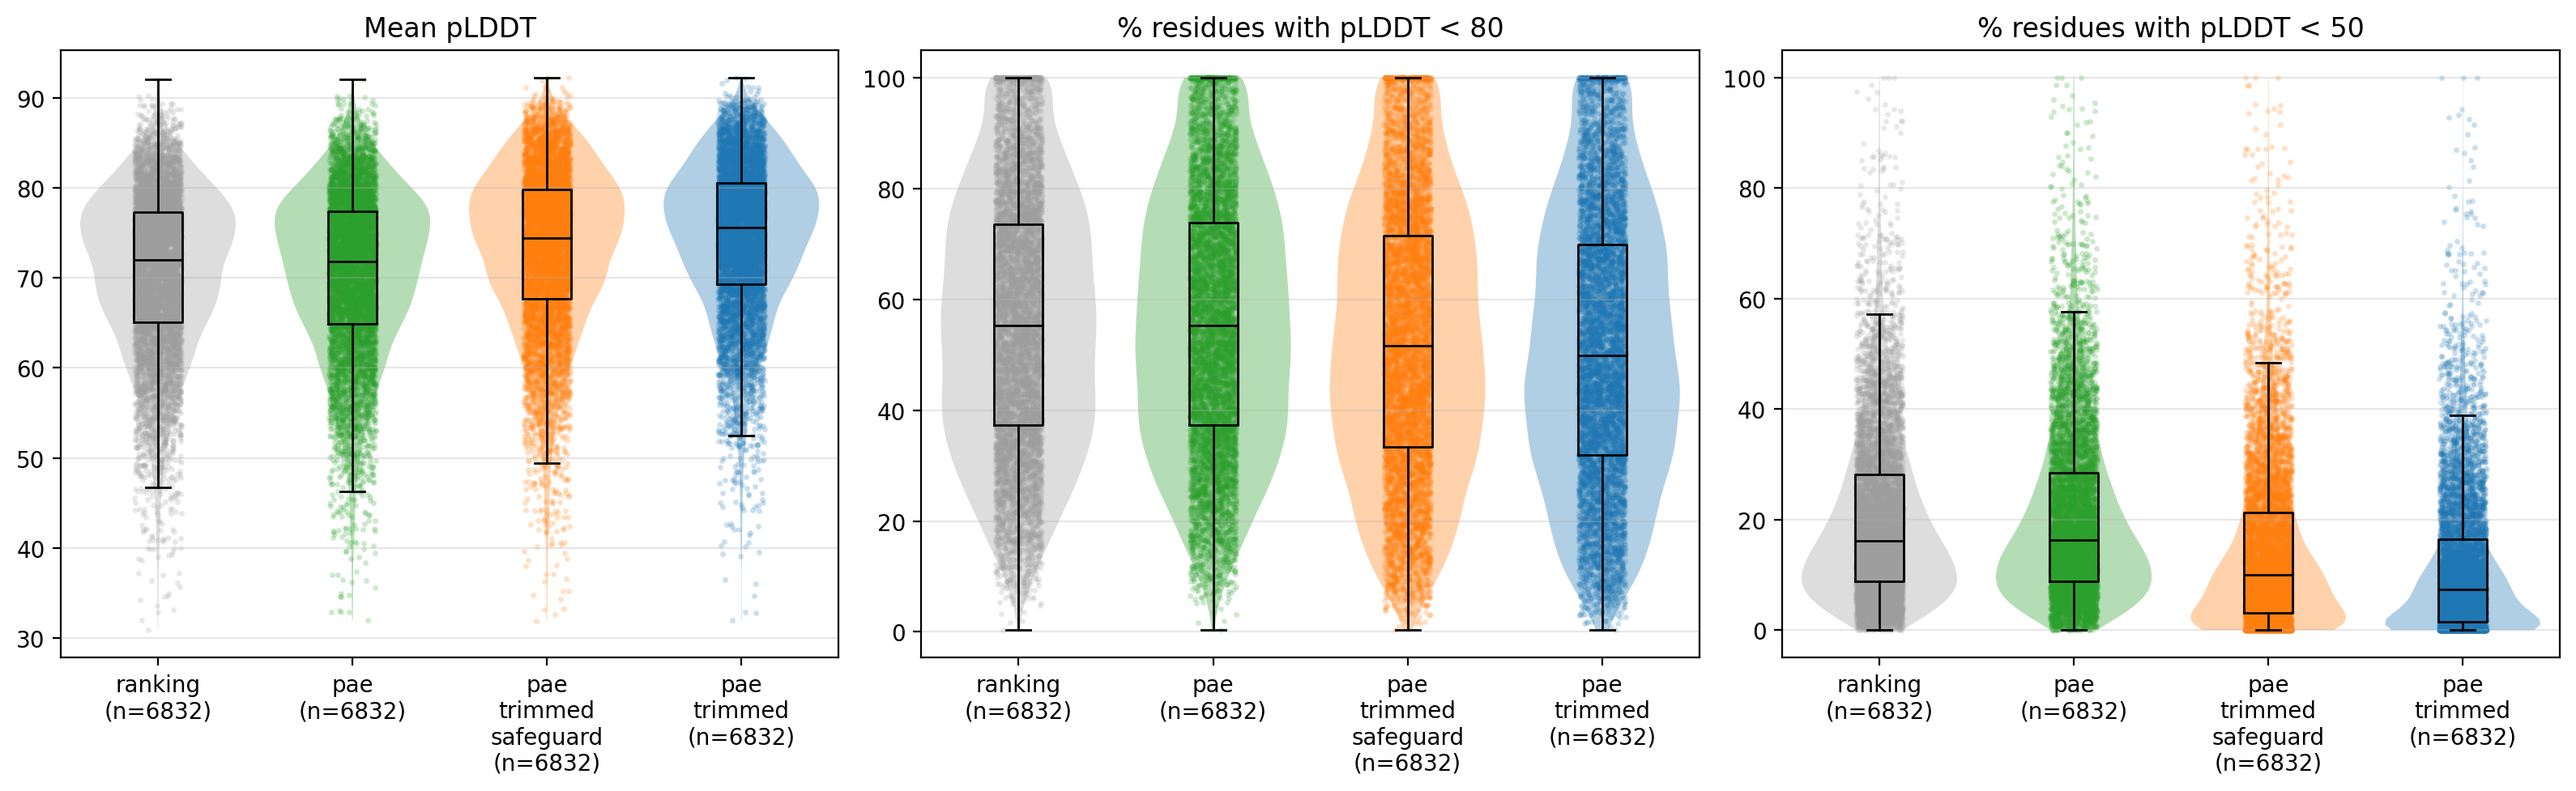

In [11]:
# %%
METRICS = [
    ("mean_plddt", "Mean pLDDT"),
    ("pct_lt80", "% residues with pLDDT < 80"),
    ("pct_lt50", "% residues with pLDDT < 50"),
]

PLOT_ORDER = ["ranking", "pae", "pae_trimmed_safeguard", "pae_trimmed"]
assert sorted(PLOT_ORDER) == sorted(SETS), f"PLOT_ORDER {PLOT_ORDER} does not match SETS {SETS}"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
rng = np.random.default_rng(0)
for ax, (col, label) in zip(axes, METRICS):
    data = [df_common.filter(pl.col("set") == s)[col].to_numpy() for s in PLOT_ORDER]
    parts = ax.violinplot(data, showextrema=False, widths=0.8)
    for body, s in zip(parts["bodies"], PLOT_ORDER):
        body.set_facecolor(COLORS[s]); body.set_alpha(0.35)
    ax.boxplot(data, widths=0.25, showfliers=False, medianprops=dict(color="k"))
    for i, (d, s) in enumerate(zip(data, PLOT_ORDER), start=1):
        ax.scatter(i + rng.uniform(-0.12, 0.12, len(d)), d, s=3, alpha=0.15, color=COLORS[s])
    ax.set_xticks(range(1, len(PLOT_ORDER) + 1),
                  [f"{s.replace('_', chr(10))}\n(n={len(d)})" for s, d in zip(PLOT_ORDER, data)])
    ax.set_title(label)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

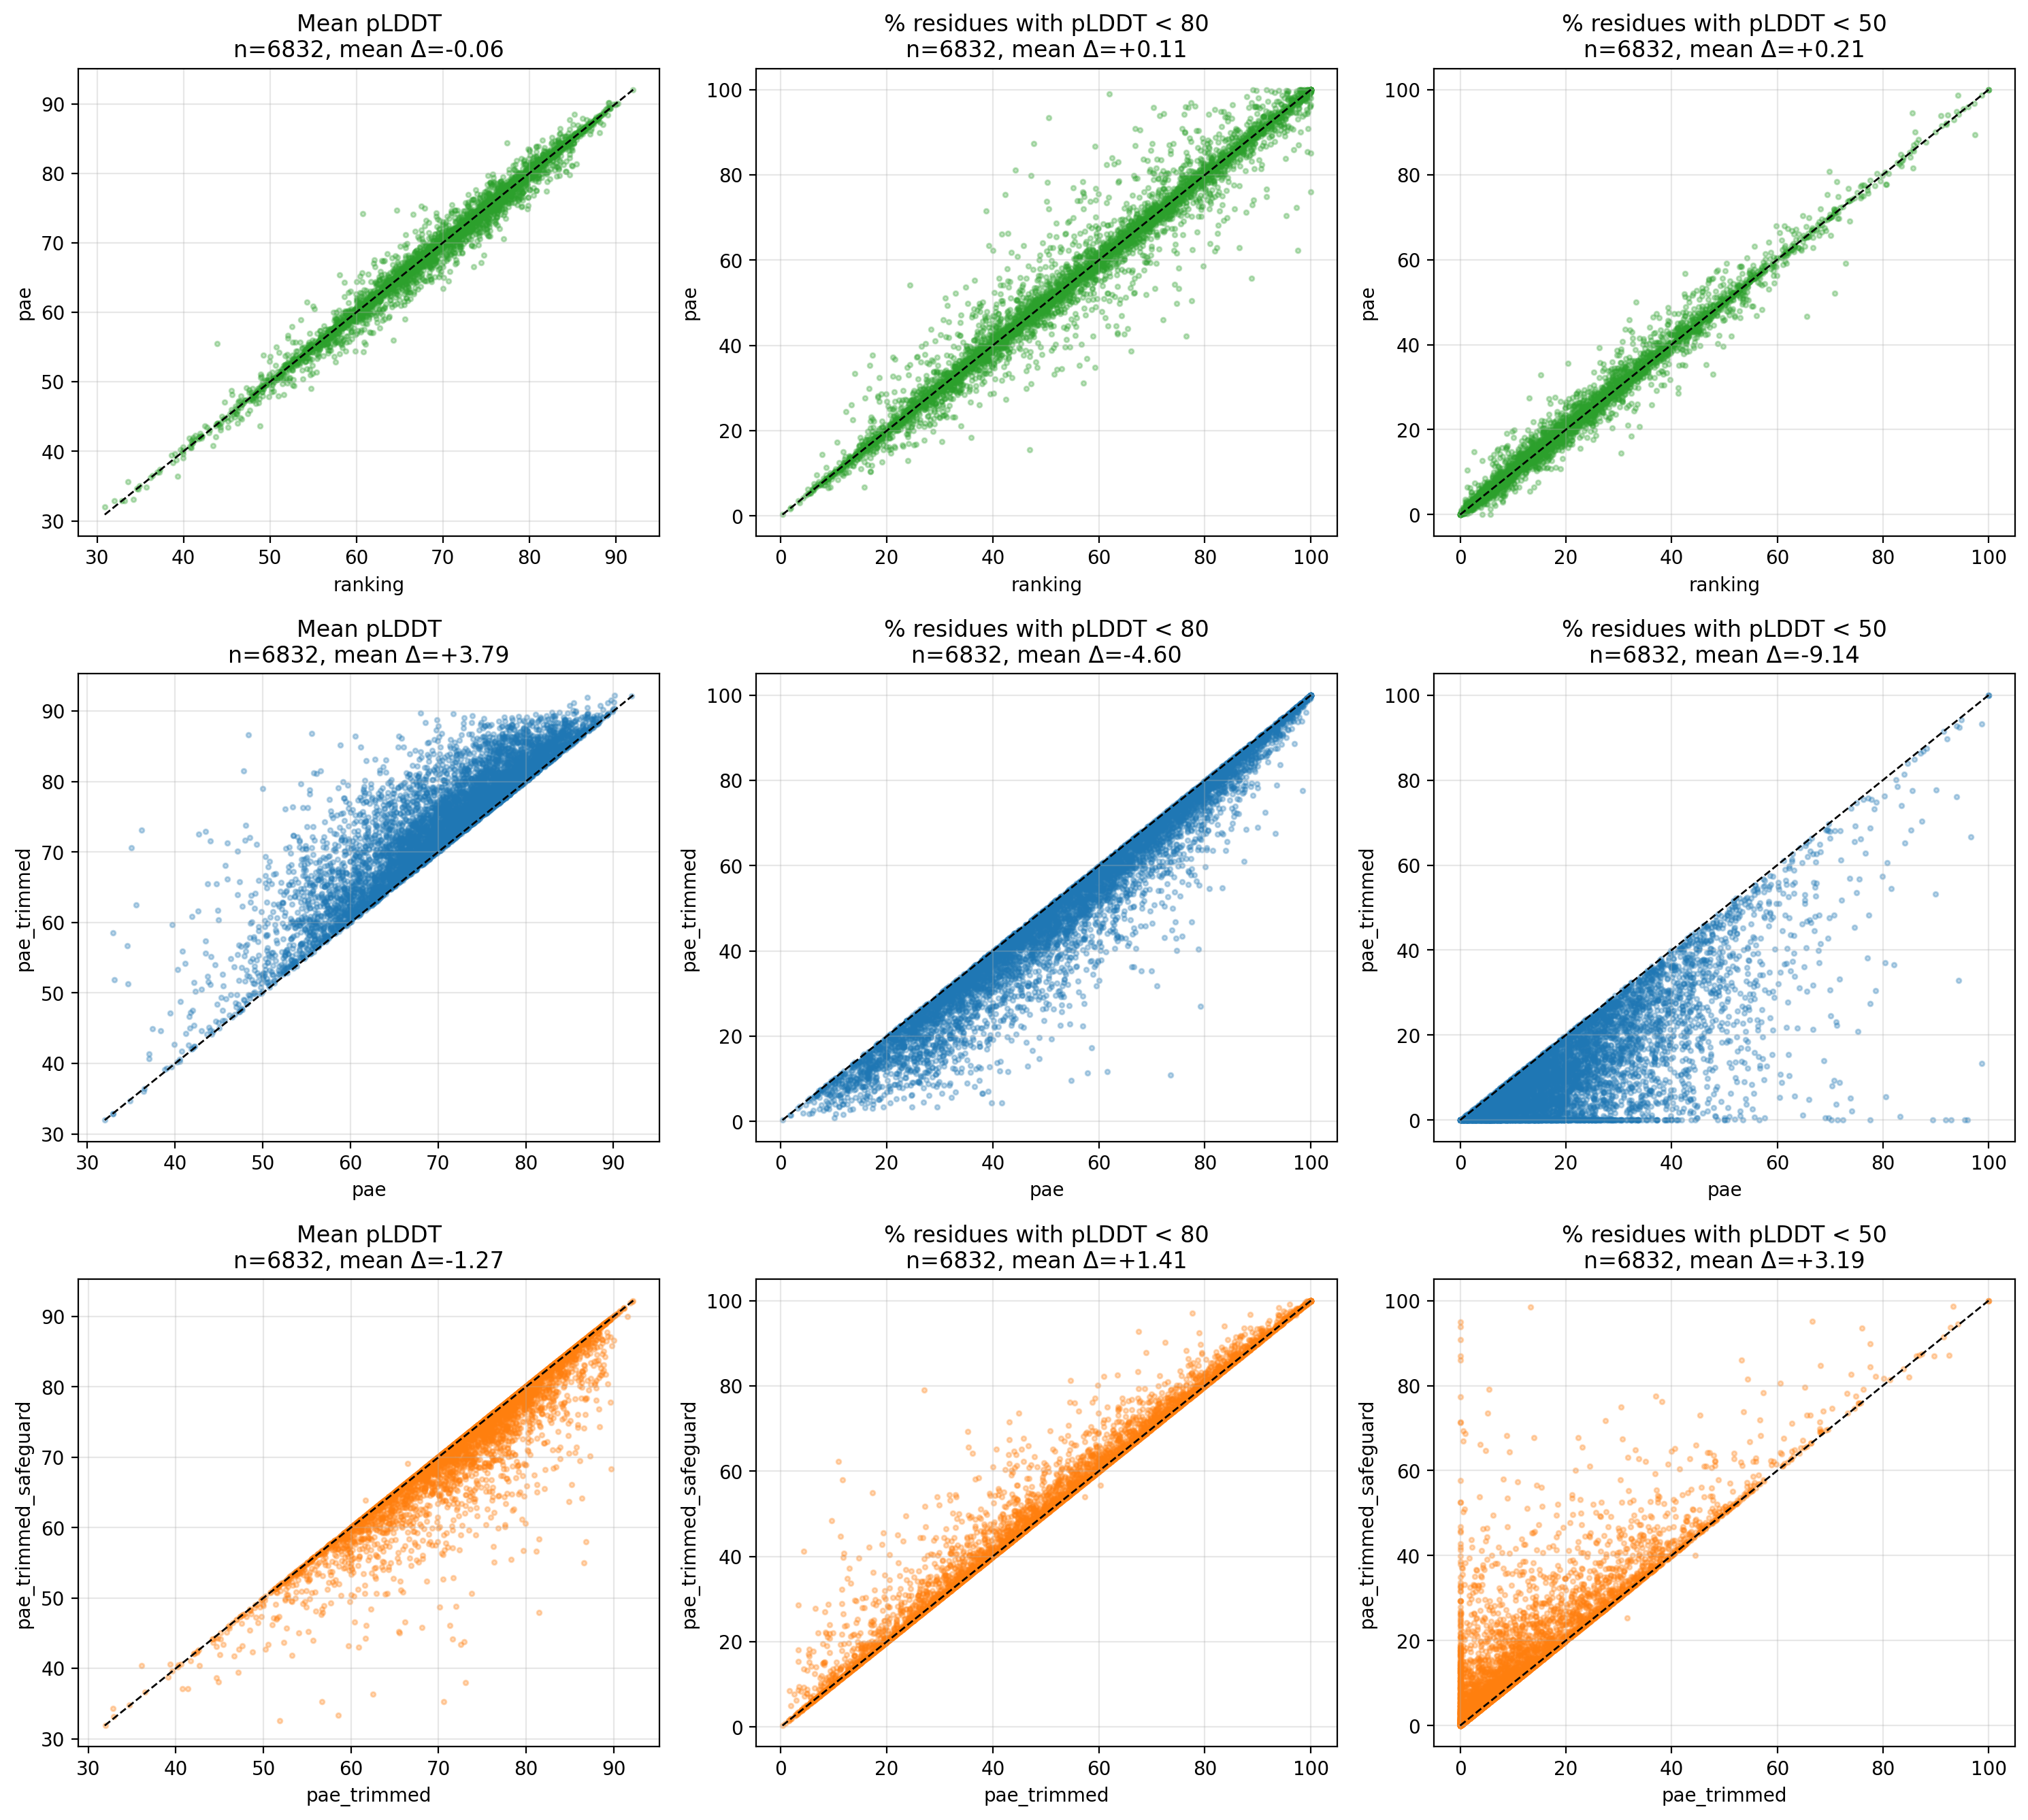

In [12]:

# ### Paired comparison between consecutive pipeline steps (only pairs present in both)
# Below the diagonal = lower value in the later step (for % metrics: fewer low-confidence residues).

# %%
wide = df_common.pivot(on="set", index="pair", values=[m for m, _ in METRICS])
for col, _ in METRICS:
    for s in SETS:
        assert f"{col}_{s}" in wide.columns, f"missing column {col}_{s}"

comparisons = list(zip(SETS[:-1], SETS[1:]))

fig, axes = plt.subplots(len(comparisons), 3, figsize=(15, 4.5 * len(comparisons)))
for r, (a, b) in enumerate(comparisons):
    for c, (col, label) in enumerate(METRICS):
        ax = axes[r, c]
        sub = wide.select(f"{col}_{a}", f"{col}_{b}").drop_nulls()  # explicit intersection
        x, y = sub[f"{col}_{a}"].to_numpy(), sub[f"{col}_{b}"].to_numpy()
        ax.scatter(x, y, s=6, alpha=0.3, color=COLORS[b])
        lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_xlabel(a); ax.set_ylabel(b)
        ax.set_title(f"{label}\nn={len(x)}, mean Δ={np.mean(y - x):+.2f}")
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# %% per metric: 2x2 grid (one panel per set), benchmark left / novel right
METRICS = [
    ("mean_plddt", "Mean pLDDT"),
    ("pct_lt80", "% residues with pLDDT < 80"),
    ("pct_lt50", "% residues with pLDDT < 50"),
]
GROUPS = ["benchmark", "novel"]


def plot_benchmark_vs_novel(df_grouped, col, label):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)
    rng = np.random.default_rng(0)
    for ax, s in zip(axes.flat, PLOT_ORDER):
        df_set = df_grouped.filter(pl.col("set") == s)
        data = [df_set.filter(pl.col("group") == g)[col].to_numpy() for g in GROUPS]
        assert all(len(d) > 0 for d in data), f"empty group in {s}"
        parts = ax.violinplot(data, showextrema=False, widths=0.8)
        for body in parts["bodies"]:
            body.set_facecolor(COLORS[s]); body.set_alpha(0.35)
        ax.boxplot(data, widths=0.25, showfliers=False, medianprops=dict(color="k"))
        for i, d in enumerate(data, start=1):
            ax.scatter(i + rng.uniform(-0.12, 0.12, len(d)), d, s=3, alpha=0.2, color=COLORS[s])
        ax.set_xticks([1, 2], [f"{g}\n(n={len(d)}, median={np.median(d):.1f})" for g, d in zip(GROUPS, data)])
        ax.set_title(s.replace("_", " "))
        ax.grid(axis="y", alpha=0.3)
    for ax in axes[:, 0]:
        ax.set_ylabel(label)
    fig.suptitle(label, fontsize=14)
    plt.tight_layout()
    plt.show()

shape: (3, 2)
┌───────────┬───────┐
│ group     ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ benchmark ┆ 1855  │
│ both      ┆ 181   │
│ novel     ┆ 4803  │
└───────────┴───────┘
shape: (8, 3)
┌───────────────────────┬───────────┬──────┐
│ set                   ┆ group     ┆ len  │
│ ---                   ┆ ---       ┆ ---  │
│ str                   ┆ str       ┆ u32  │
╞═══════════════════════╪═══════════╪══════╡
│ pae                   ┆ benchmark ┆ 1851 │
│ pae                   ┆ novel     ┆ 4800 │
│ pae_trimmed           ┆ benchmark ┆ 1851 │
│ pae_trimmed           ┆ novel     ┆ 4800 │
│ pae_trimmed_safeguard ┆ benchmark ┆ 1851 │
│ pae_trimmed_safeguard ┆ novel     ┆ 4800 │
│ ranking               ┆ benchmark ┆ 1851 │
│ ranking               ┆ novel     ┆ 4800 │
└───────────────────────┴───────────┴──────┘


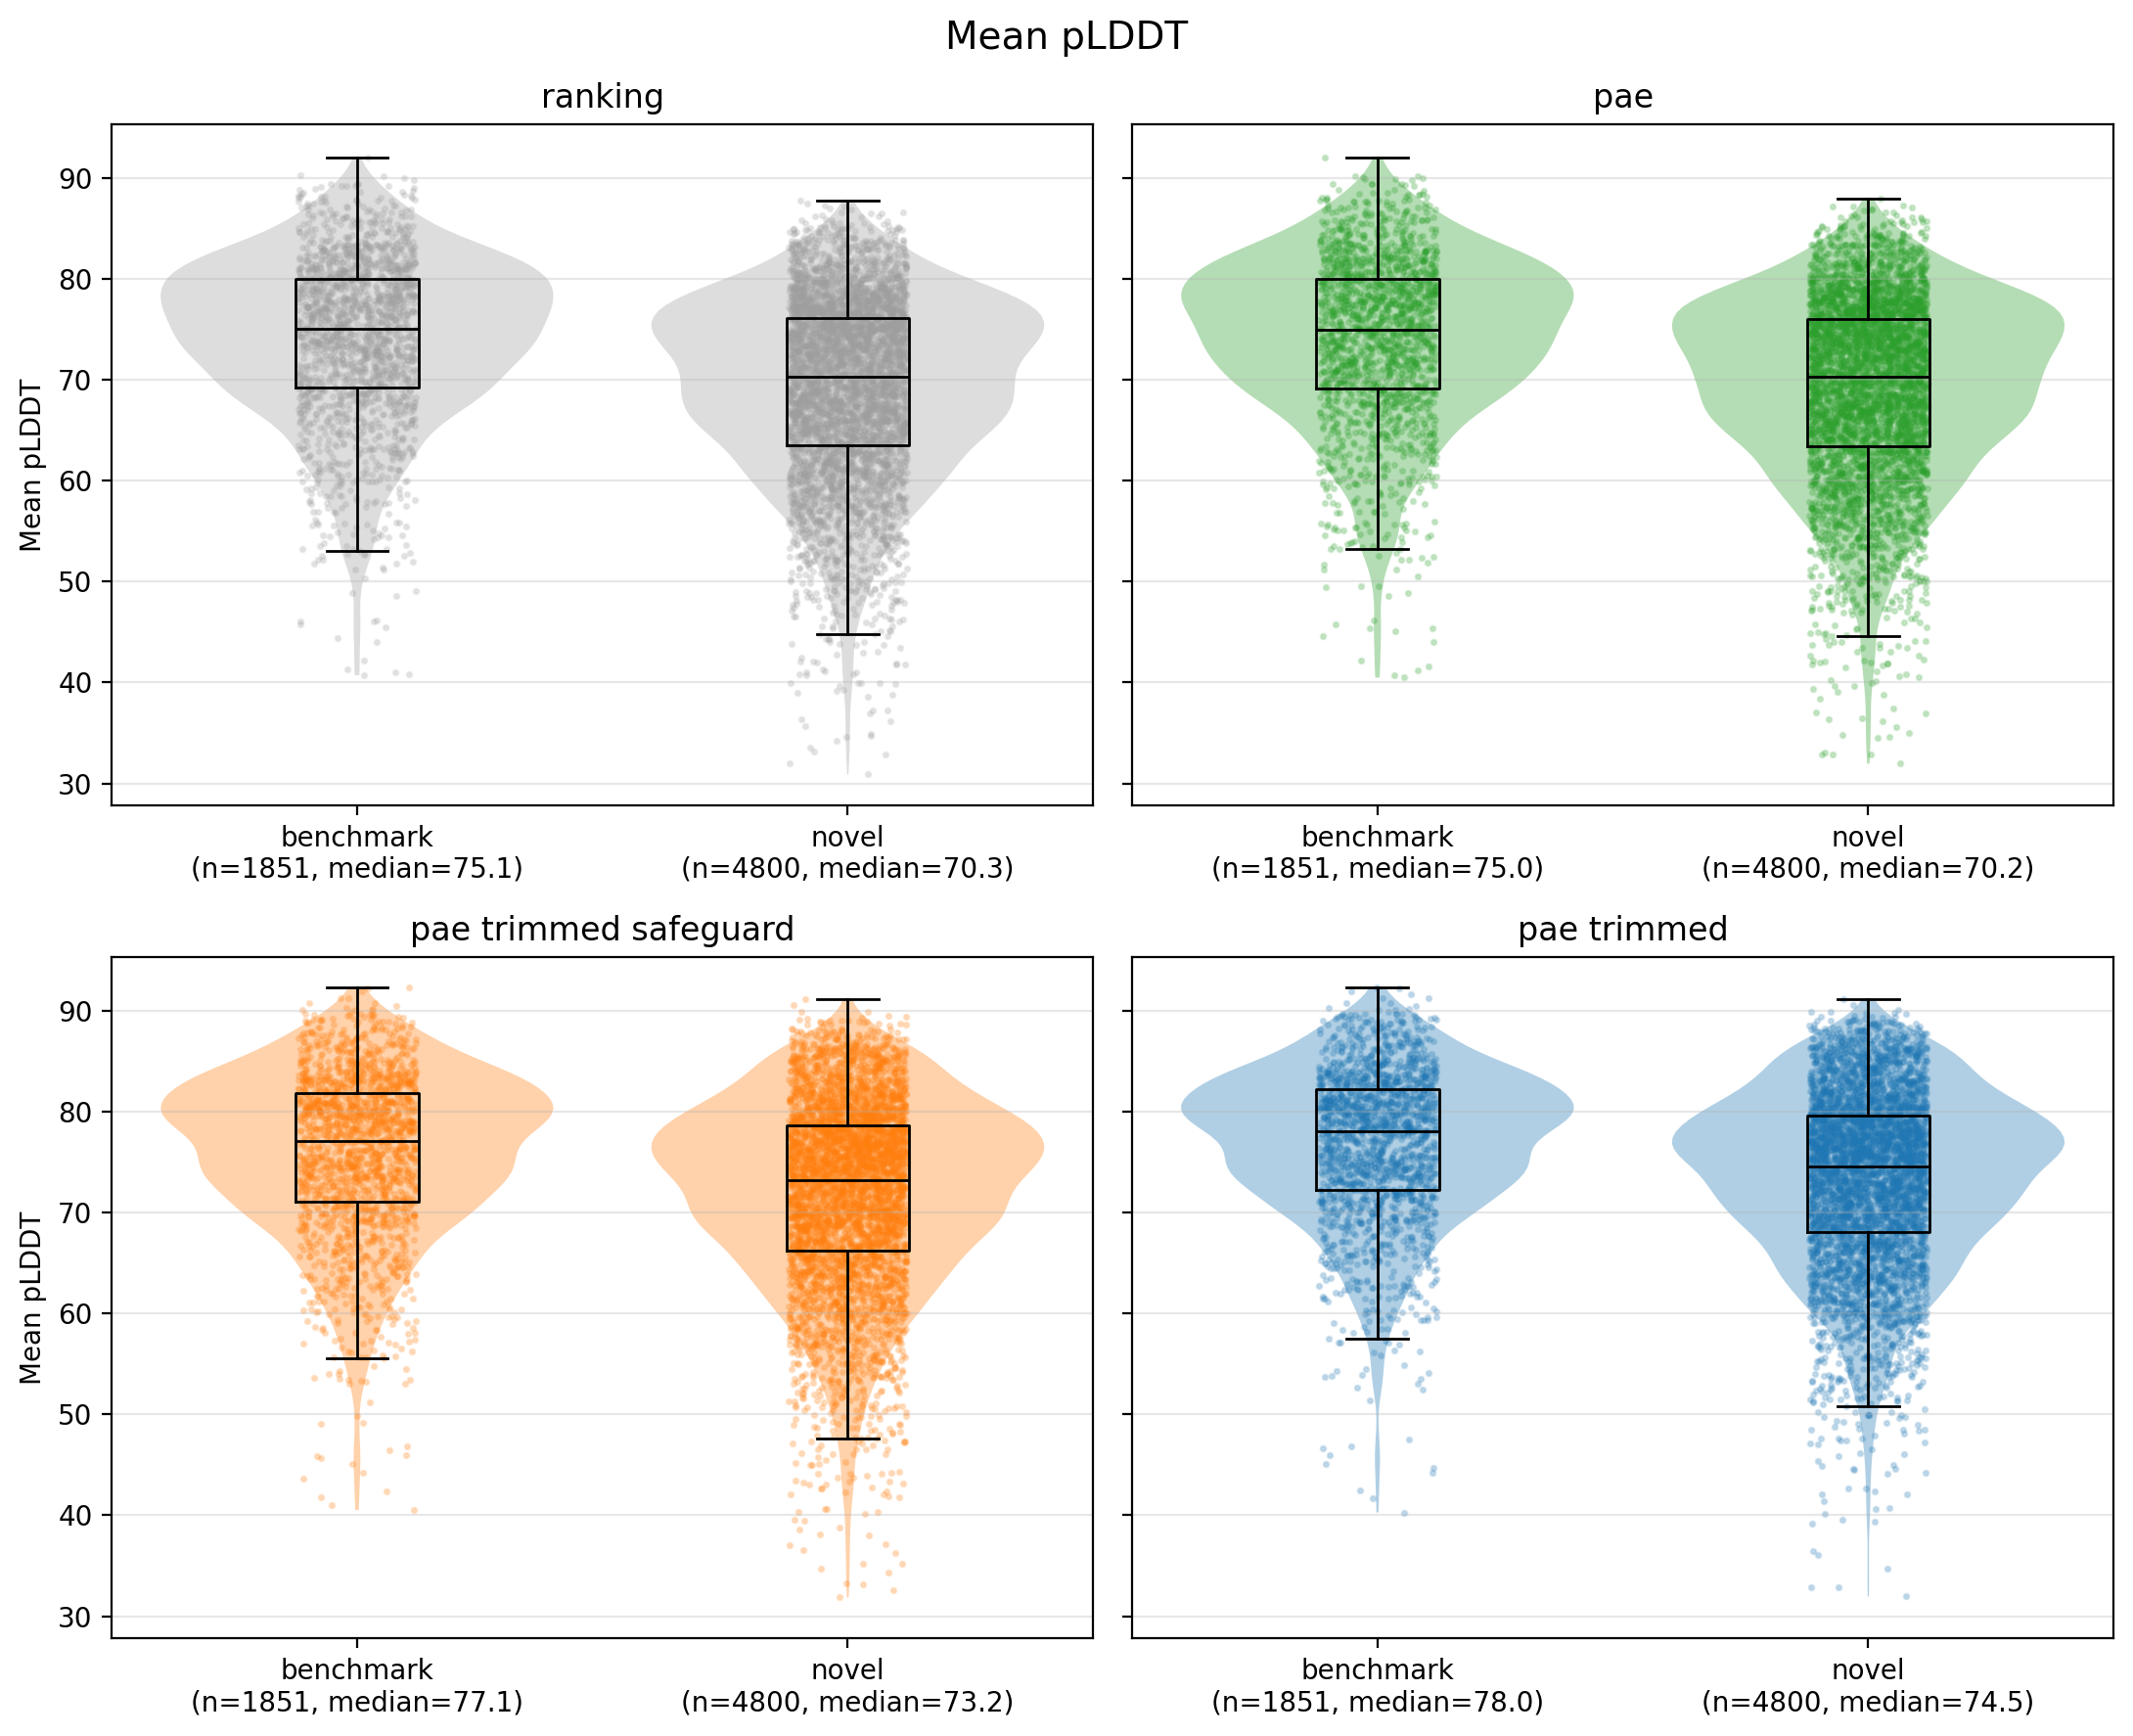

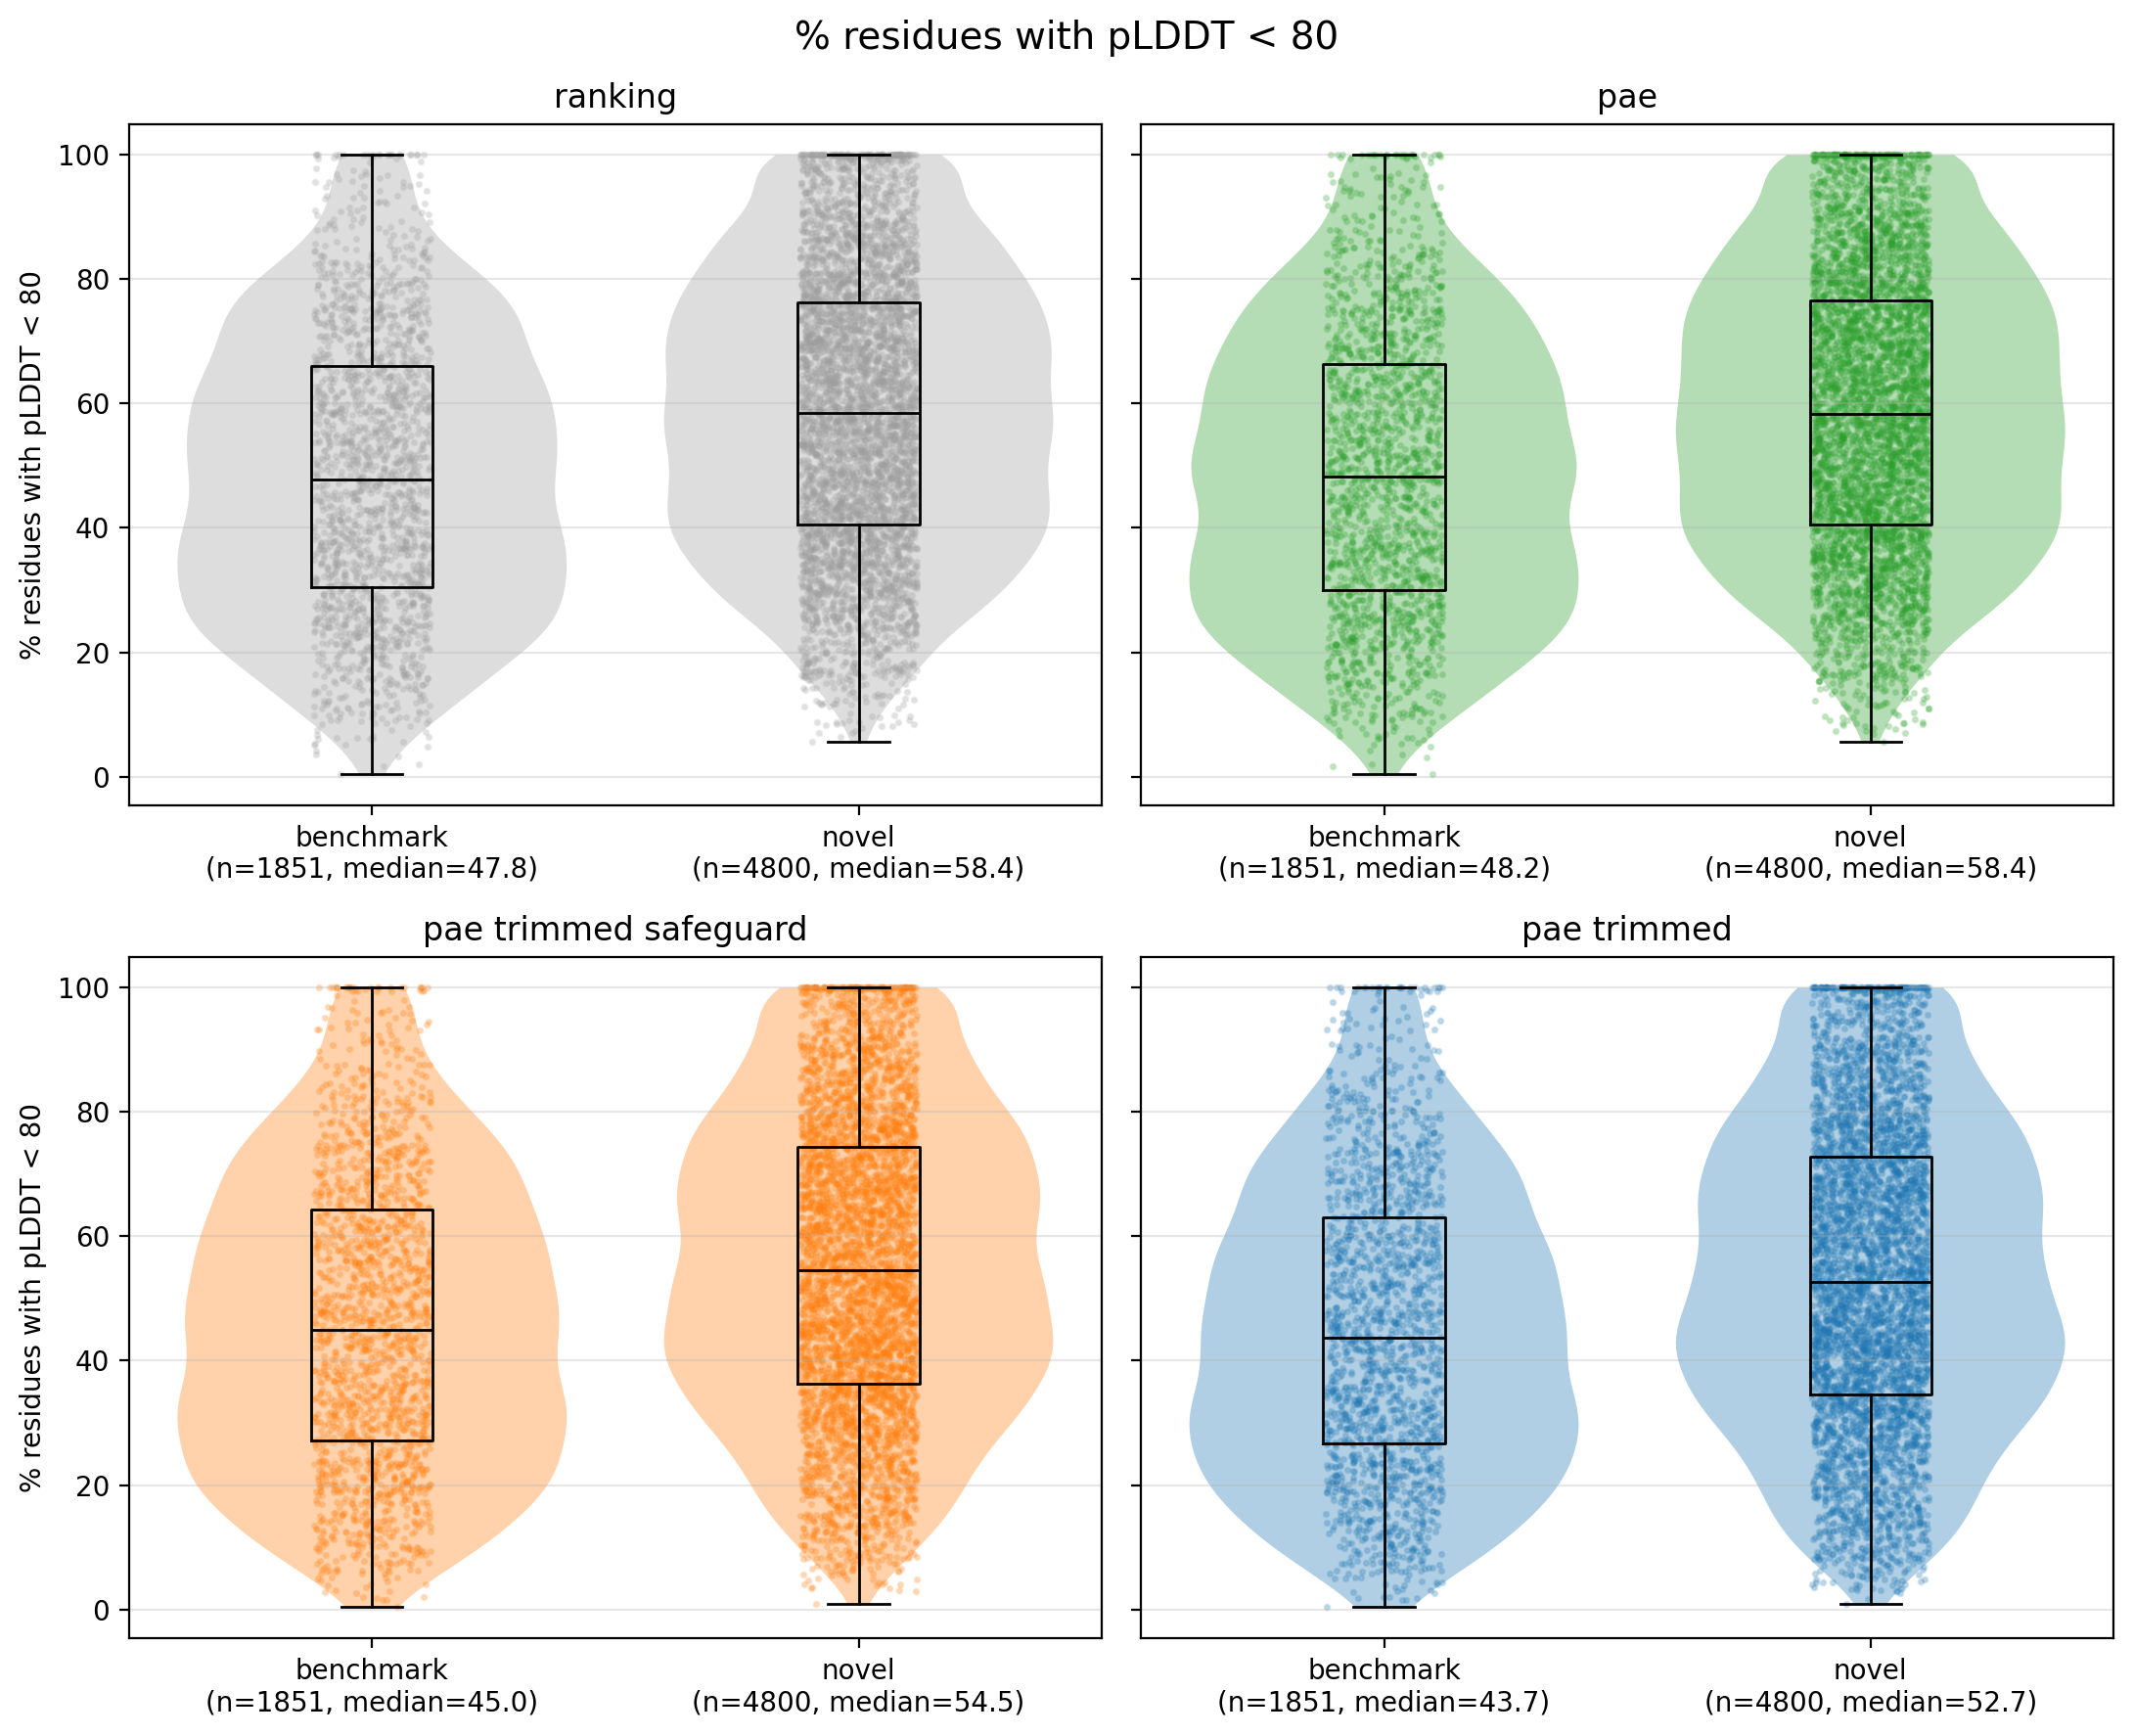

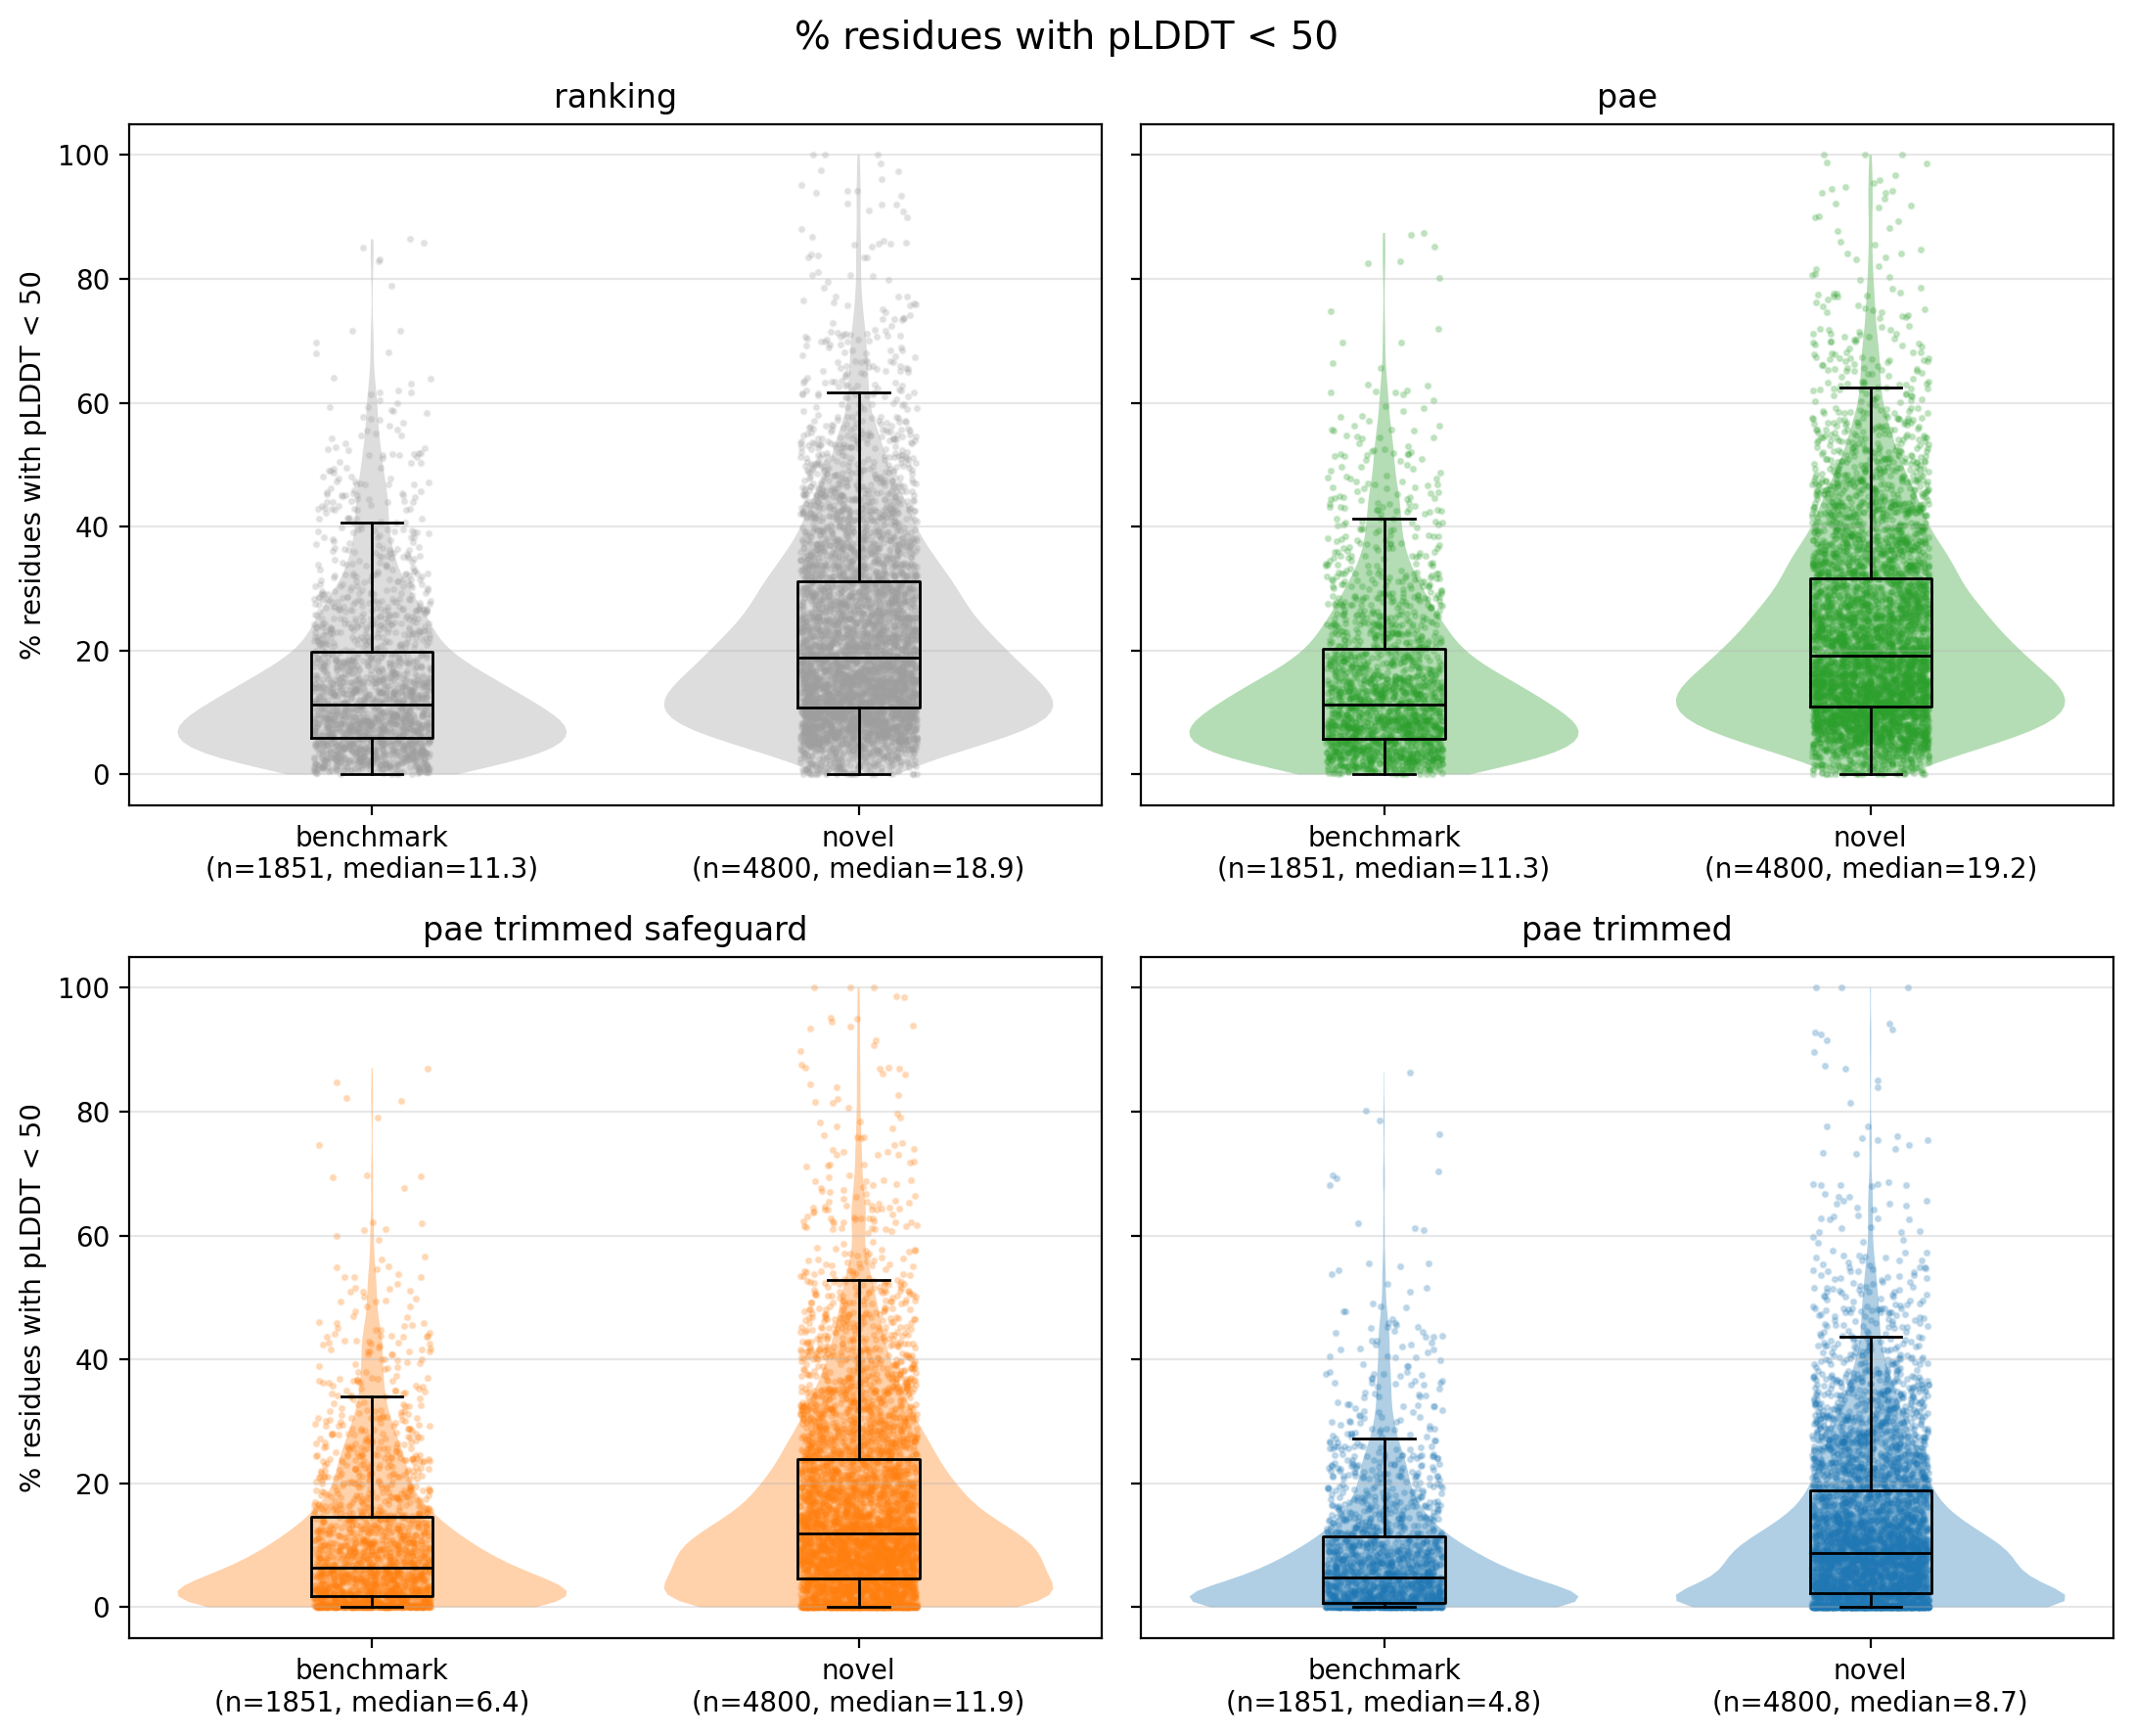

In [18]:
# %% pdb mapping: complex -> benchmark / novel
pdb_mapping_path = data_dir / "complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv"
pdb_mapping = pl.read_csv(pdb_mapping_path)
assert pdb_mapping["complex_ac"].is_unique().all(), "complex_ac not unique in mapping"

MATCH_CLASS_TO_GROUP = {
    "exact_pdb_match":      "benchmark",
    "no_homology_match":    "novel",
    "no_sufficient_match":  "novel",
}
complex_group = pdb_mapping.select(
    "complex_ac",
    pl.col("match_class").replace_strict(MATCH_CLASS_TO_GROUP, default=None).alias("group"),
)

# %% pair -> complex from the pae pool pairs metrics
pool_pairs_path = PIPE / "18_CP_model_based_on_pae/18_CP_model_based_on_pae_pool_pairs_metrics.csv"
pair_complex = pl.read_csv(pool_pairs_path, columns=["complex_ac", "pair"]).unique()

complexes_not_in_mapping = set(pair_complex["complex_ac"]) - set(pdb_mapping["complex_ac"])
assert not complexes_not_in_mapping, f"complexes missing in pdb mapping: {sorted(complexes_not_in_mapping)[:5]}"

pairs_not_in_pool_file = common_pairs - set(pair_complex["pair"])
assert not pairs_not_in_pool_file, f"{len(pairs_not_in_pool_file)} common pairs not in pool file, e.g. {sorted(pairs_not_in_pool_file)[:5]}"

# %% pair -> group; pairs in both benchmark and novel complexes are labelled 'both'
pair_group = (
    pair_complex
    .join(complex_group, on="complex_ac", how="inner")
    .group_by("pair")
    .agg(pl.col("group").unique().alias("groups"))
)
assert not pair_group["groups"].list.contains(None).any(), \
    "some pairs belong to a complex whose match_class is not in MATCH_CLASS_TO_GROUP"

pair_group = pair_group.with_columns(
    pl.when(pl.col("groups").list.len() == 1)
    .then(pl.col("groups").list.first())
    .otherwise(pl.lit("both"))
    .alias("group")
).select("pair", "group")
print(pair_group["group"].value_counts().sort("group"))

df_grouped = df_common.join(pair_group.filter(pl.col("group") != "both"), on="pair", how="inner")
assert df_grouped.height > 0
print(df_grouped.group_by("set", "group").len().sort("set", "group"))

# %%
for col, label in METRICS:
    plot_benchmark_vs_novel(df_grouped, col, label)

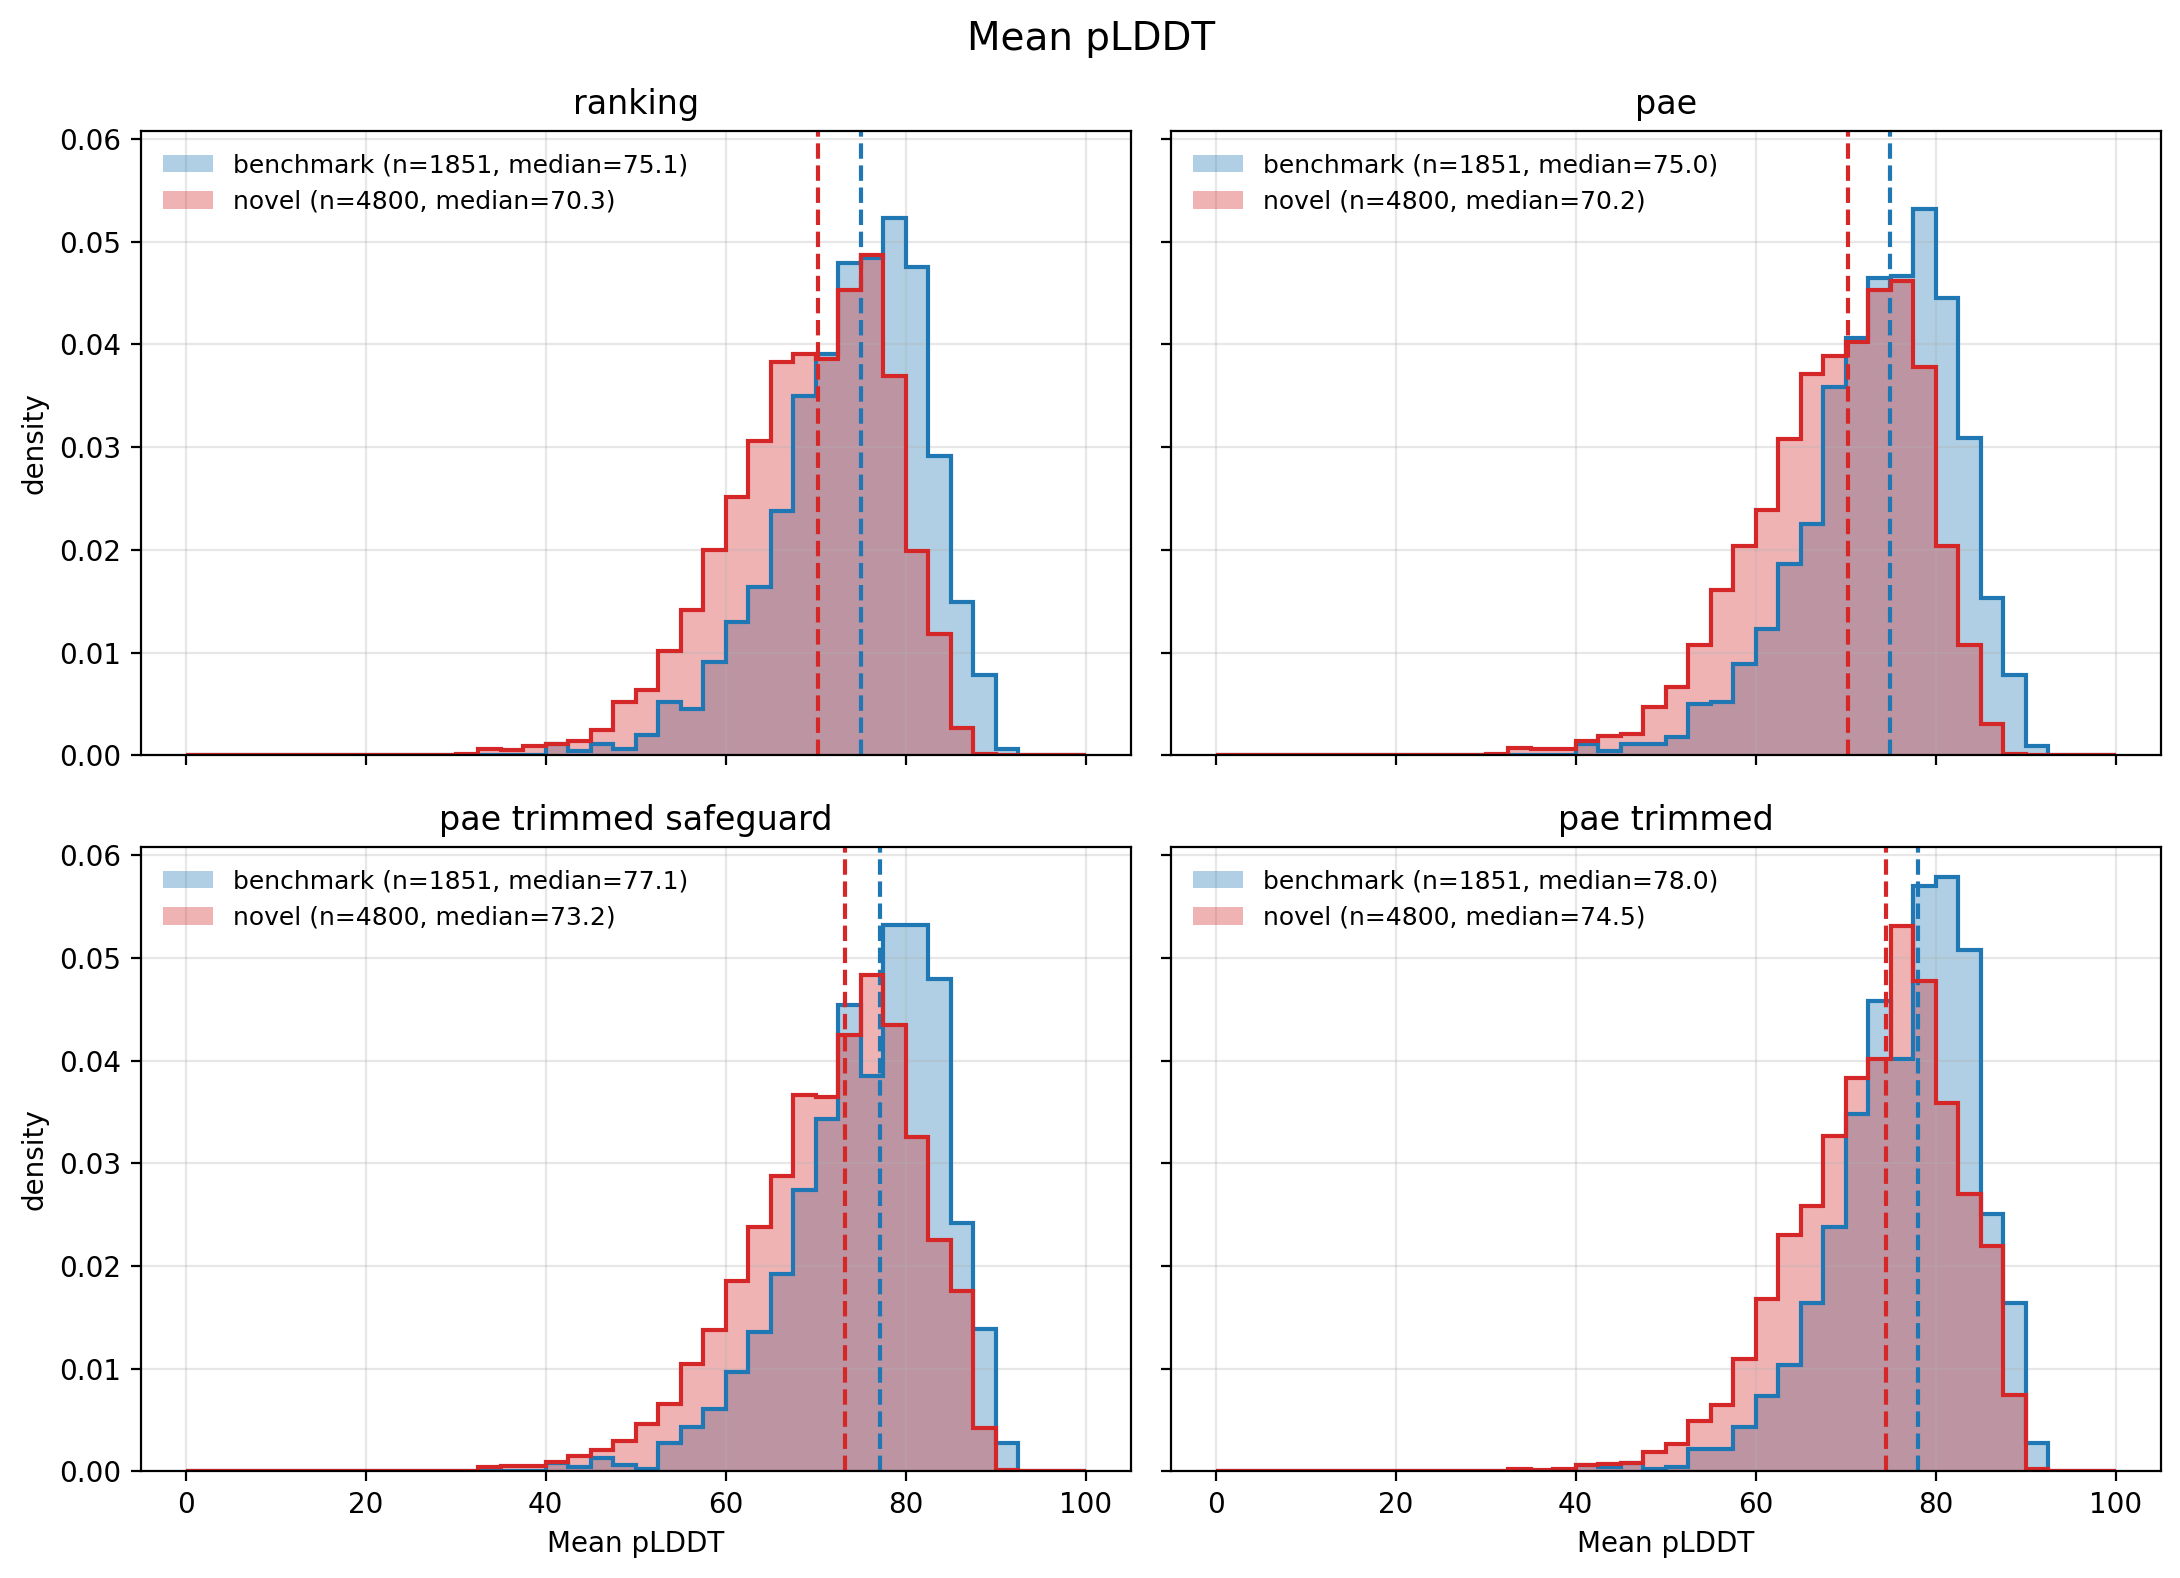

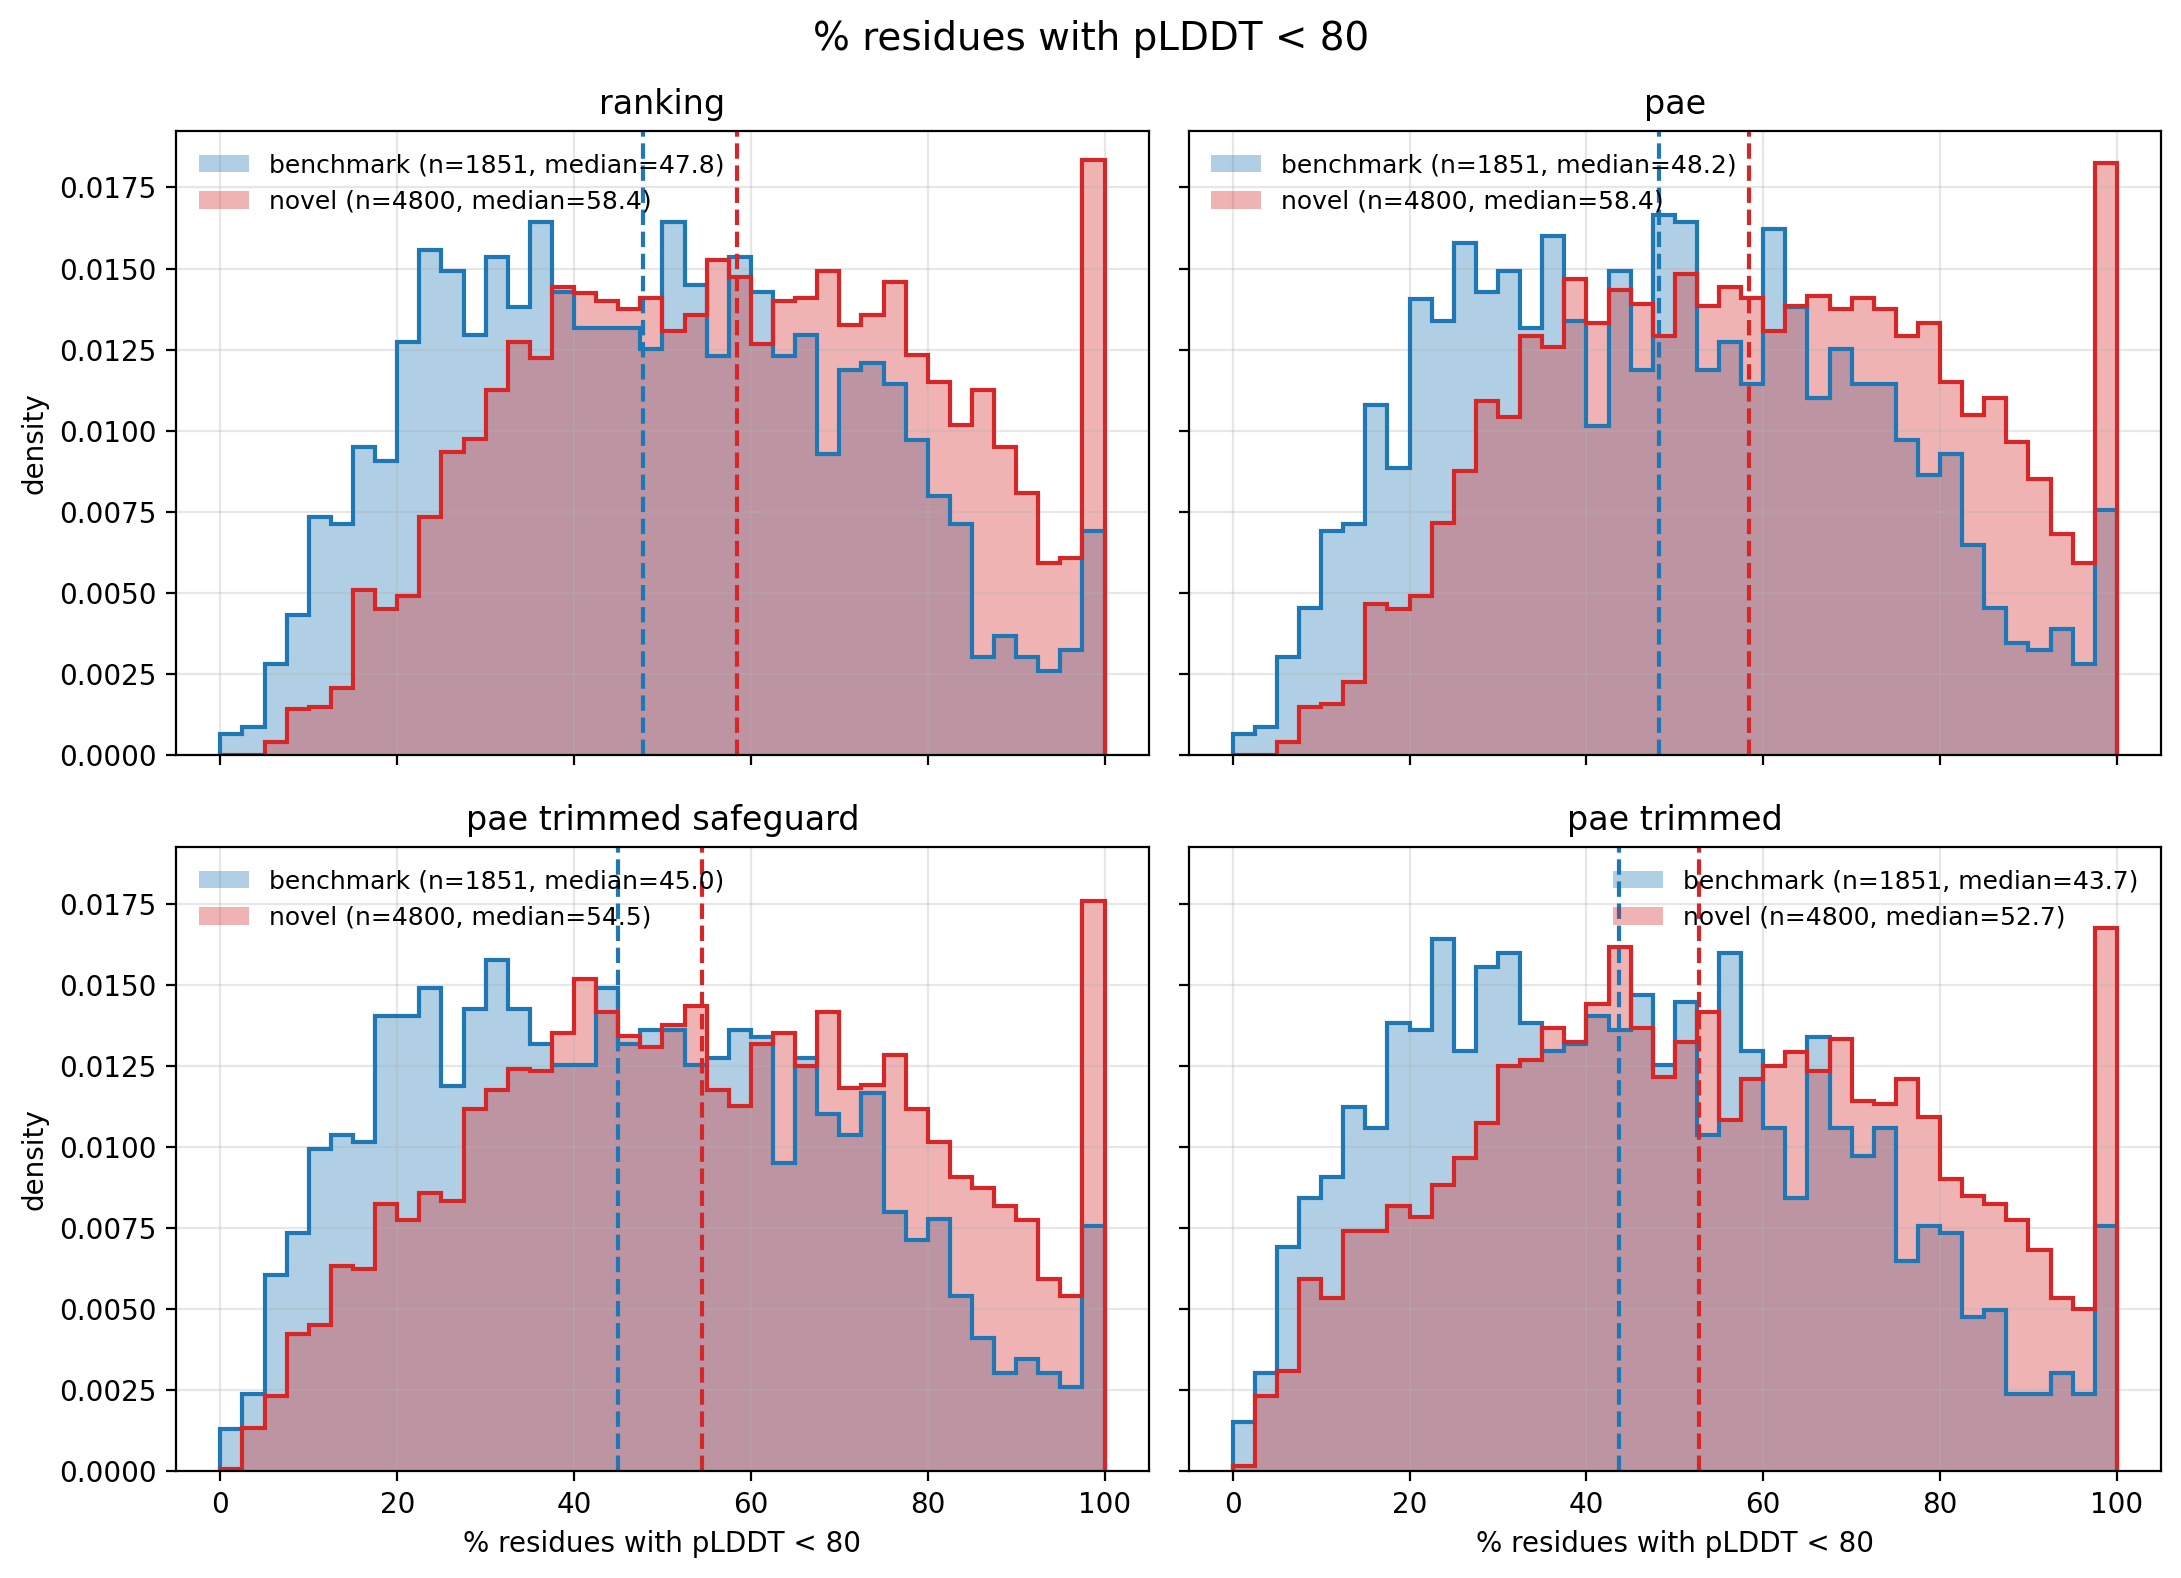

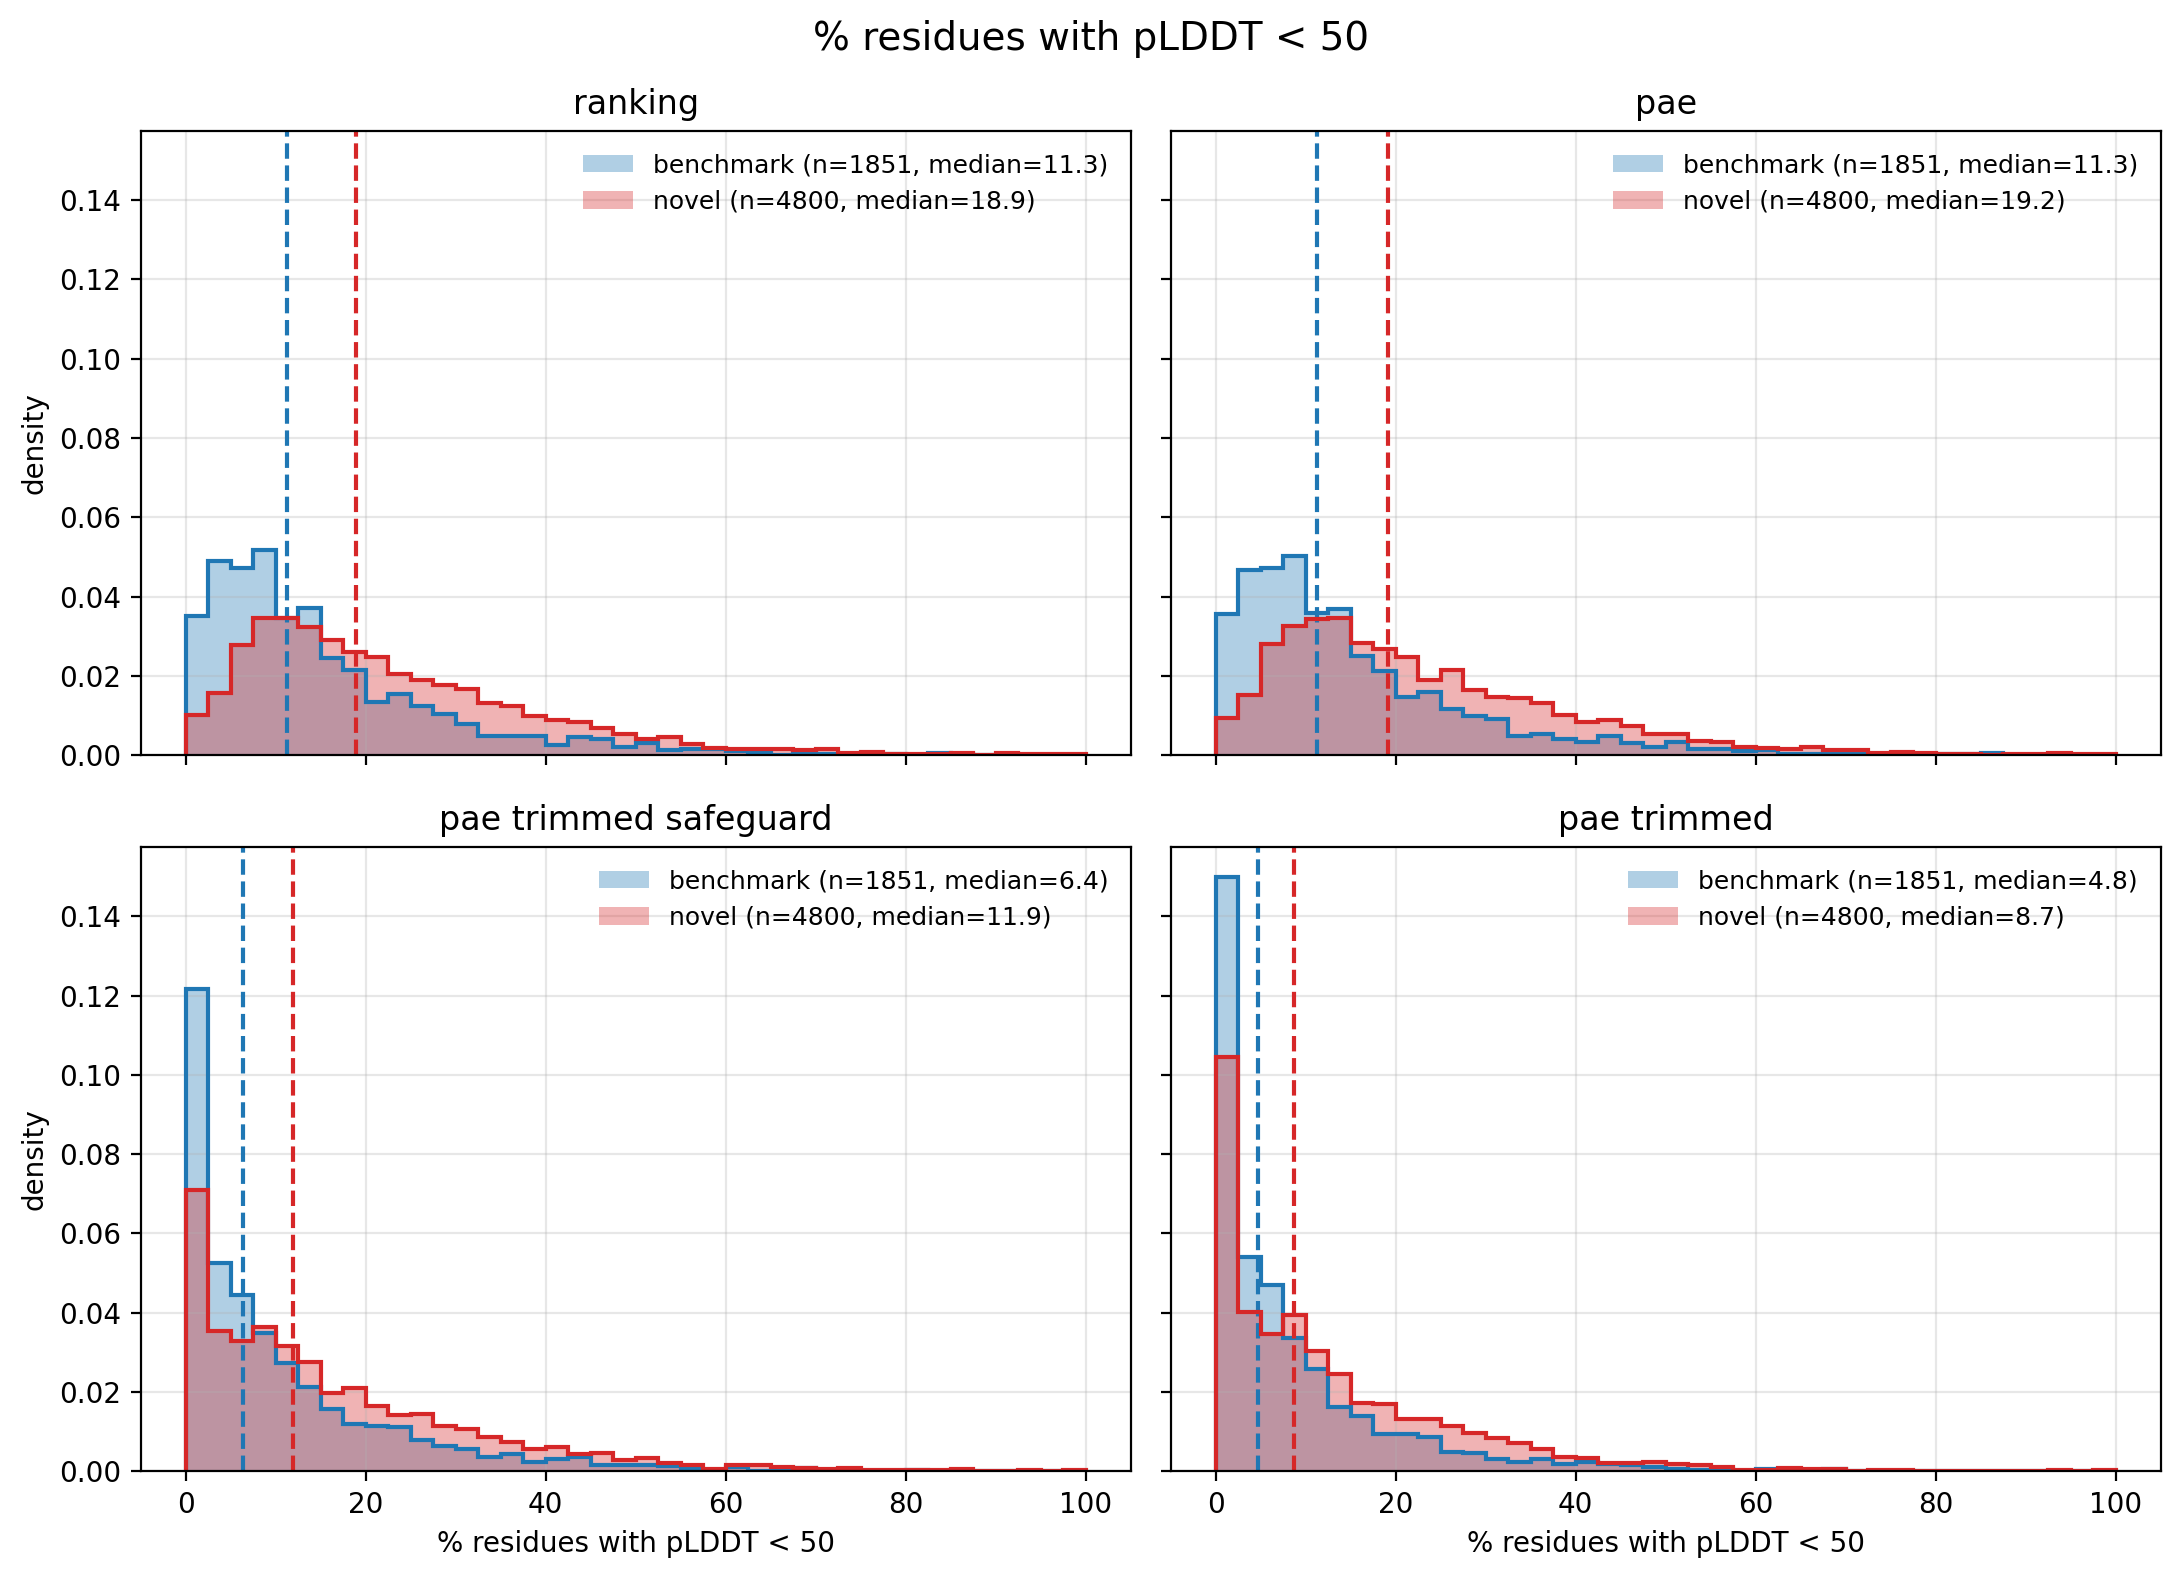

In [19]:
# %% per metric: 2x2 grid (one panel per set), benchmark vs novel as overlaid histograms
GROUP_COLORS = {"benchmark": "#1f77b4", "novel": "#d62728"}
METRIC_RANGES = {"mean_plddt": (0, 100), "pct_lt80": (0, 100), "pct_lt50": (0, 100)}


def plot_benchmark_vs_novel_hist(df_grouped, col, label, n_bins=40):
    bins = np.linspace(*METRIC_RANGES[col], n_bins + 1)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
    for ax, s in zip(axes.flat, PLOT_ORDER):
        df_set = df_grouped.filter(pl.col("set") == s)
        for g in GROUPS:
            values = df_set.filter(pl.col("group") == g)[col].to_numpy()
            assert len(values) > 0, f"empty group {g} in {s}"
            ax.hist(values, bins=bins, density=True, alpha=0.35, color=GROUP_COLORS[g],
                    label=f"{g} (n={len(values)}, median={np.median(values):.1f})")
            ax.hist(values, bins=bins, density=True, histtype="step", lw=1.5, color=GROUP_COLORS[g])
            ax.axvline(np.median(values), color=GROUP_COLORS[g], ls="--", lw=1.5)
        ax.set_title(s.replace("_", " "))
        ax.legend(frameon=False, fontsize=9)
        ax.grid(alpha=0.3)
    for ax in axes[1, :]:
        ax.set_xlabel(label)
    for ax in axes[:, 0]:
        ax.set_ylabel("density")
    fig.suptitle(label, fontsize=14)
    plt.tight_layout()
    plt.show()


for col, label in METRICS:
    plot_benchmark_vs_novel_hist(df_grouped, col, label)